## Este é o tech challenge B 
Este tech challenge tem como objetivo treinar um Modelo de IA para efetuar a triagem de pacientes com base nos dados coletados e categorizar eles em uma escala de risco de 0 a 3 onde 0 é aquele que apresenta o menor risco e 3 é o de maior risco

## 1) Importação de bibliotecas e configuração de exibição

Nesta etapa importamos todas as bibliotecas que serão utilizadas no projeto e ajustamos opções de visualização para facilitar a leitura das tabelas no notebook.

In [ ]:
# Manipulação e análise de dados tabulares
import pandas as pd

# Computação numérica e manipulação de arrays/matrizes
import numpy as np

# Criação de visualizações de dados e gráficos
import matplotlib.pyplot as plt

# Conversão de variáveis categóricas (texto) para numéricas
from sklearn.preprocessing import LabelEncoder

# Separação dos dados em conjuntos de treino e teste
from sklearn.model_selection import train_test_split

# Algoritmo de Árvore de Decisão para classificação
from sklearn.tree import DecisionTreeClassifier

# Módulo de árvores do scikit-learn
from sklearn import tree

# Métrica de avaliação: calcula a taxa de acertos (acurácia) do modelo
from sklearn.metrics import accuracy_score 

# Ferramentas para avaliação detalhada do modelo
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Algoritmo de Floresta Aleatória (Random Forest) para classificação
from sklearn.ensemble import RandomForestClassifier

# Técnica para lidar com dados desbalanceados (cria exemplos sintéticos da classe minoritária)
from imblearn.over_sampling import SMOTE

# Interpretabilidade: importância por permutação e SHAP
from sklearn.inspection import permutation_importance
import shap

# Configurações de visualização do pandas no notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 2) Carregamento do dataset

Aqui lemos o arquivo `synthetic_medical_triage.csv` para a variável `df` e mostramos as primeiras linhas para validar se os dados foram carregados corretamente.  
Fonte: https://www.kaggle.com/datasets/ilkeryildiz/emergency-service-triage-application/data

In [61]:
df = pd.read_csv("../data/synthetic_medical_triage.csv")

df.head()

,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


## 3) Dimensão e colunas do dataset

Calculamos a quantidade de linhas e colunas (`shape`) e listamos os nomes das colunas para entender a estrutura geral dos dados.

In [62]:
n_linhas, n_colunas = df.shape

print(f"Quantidade de linhas: {n_linhas}")
print(f"Quantidade de colunas: {n_colunas}")
print("\nColunas do dataset:")
print(df.columns.tolist())

Quantidade de linhas: 18000
Quantidade de colunas: 10

Colunas do dataset:
['age', 'heart_rate', 'systolic_blood_pressure', 'oxygen_saturation', 'body_temperature', 'pain_level', 'chronic_disease_count', 'previous_er_visits', 'arrival_mode', 'triage_level']


## 4) Tipos de dados e campos preenchidos

Usamos `df.info()` para verificar tipos das variáveis, quantidade de valores não nulos e consumo de memória.

In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      18000 non-null  float64
 1   heart_rate               18000 non-null  float64
 2   systolic_blood_pressure  18000 non-null  float64
 3   oxygen_saturation        18000 non-null  float64
 4   body_temperature         18000 non-null  float64
 5   pain_level               18000 non-null  int64  
 6   chronic_disease_count    18000 non-null  int64  
 7   previous_er_visits       18000 non-null  int64  
 8   arrival_mode             18000 non-null  str    
 9   triage_level             18000 non-null  int64  
dtypes: float64(5), int64(4), str(1)
memory usage: 1.4 MB


## 5) Estatísticas descritivas

Geramos um resumo estatístico das variáveis numéricas (média, desvio padrão, mínimos, máximos e quartis) para identificar escala e dispersão dos dados.

In [64]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,18000.0,44.716244,19.101056,0.00,31.20,44.00,57.50,95.00
heart_rate,18000.0,83.292322,16.964405,33.40,71.50,81.60,93.20,152.30
systolic_blood_pressure,18000.0,128.072739,18.813277,65.80,114.90,126.90,139.90,219.70
oxygen_saturation,18000.0,96.085183,3.330830,79.50,94.30,96.60,98.70,100.00
body_temperature,18000.0,37.224236,0.914978,34.47,36.58,37.12,37.77,41.13
pain_level,18000.0,3.402111,2.039249,1.00,2.00,3.00,5.00,10.00
chronic_disease_count,18000.0,1.072611,1.312204,0.00,0.00,1.00,2.00,10.00
previous_er_visits,18000.0,1.265056,1.454887,0.00,0.00,1.00,2.00,11.00
triage_level,18000.0,0.697722,0.898923,0.00,0.00,0.00,1.00,3.00


## 6) Análise de valores ausentes

Contamos valores nulos por coluna e o total de ausências no dataset para avaliar necessidade de tratamento antes da modelagem.

In [65]:
missing = df.isnull().sum().sort_values(ascending=False)
total_missing = int(missing.sum())
print(f"Total de valores ausentes no dataset original: {total_missing}\n")
print("Ausentes por coluna:")
display(missing.to_frame("qtd_ausentes"))


Total de valores ausentes no dataset original: 0

Ausentes por coluna:


,qtd_ausentes
age,0
heart_rate,0
systolic_blood_pressure,0
oxygen_saturation,0
body_temperature,0
pain_level,0
chronic_disease_count,0
previous_er_visits,0
arrival_mode,0
triage_level,0


### 7.0) Limpeza e qualidade dos dados (`clean_df`)

Gera `clean_df` para modelagem: remoção de valores duplicados, padronização de `arrival_mode`, correção numérica, recortes plausíveis e relatório de ausentes apos correção (inválidos viram `NaN` e são tratados no pipeline).


In [66]:

clean_df = df.copy()
n_before = len(clean_df)
clean_df = clean_df.drop_duplicates()
removed_duplicates = n_before - len(clean_df)

if "arrival_mode" in clean_df.columns:
    clean_df["arrival_mode"] = (
        clean_df["arrival_mode"].astype("string").str.strip().str.lower()
    )

numeric_cols_expected = [
    "age", "heart_rate", "systolic_blood_pressure", "oxygen_saturation",
    "body_temperature", "pain_level", "chronic_disease_count",
    "previous_er_visits", "triage_level",
]
for col in numeric_cols_expected:
    if col in clean_df.columns:
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

if "pain_level" in clean_df.columns:
    clean_df["pain_level"] = clean_df["pain_level"].clip(0, 10)
if "oxygen_saturation" in clean_df.columns:
    clean_df["oxygen_saturation"] = clean_df["oxygen_saturation"].clip(0, 100)

for col in ["age", "heart_rate", "systolic_blood_pressure", "body_temperature",
            "chronic_disease_count", "previous_er_visits"]:
    if col in clean_df.columns:
        clean_df[col] = clean_df[col].clip(lower=0)

na_report = clean_df.isna().sum().sort_values(ascending=False)
print(f"Registros removidos por duplicidade: {removed_duplicates}")
print("\nValores ausentes apos padronização/correção:")
display(na_report.to_frame("missing_count"))
print("\nAmostra após limpeza:")
display(clean_df.head())


Registros removidos por duplicidade: 0

Valores ausentes apos padronização/correção:


,missing_count
age,0
heart_rate,0
systolic_blood_pressure,0
oxygen_saturation,0
body_temperature,0
pain_level,0
chronic_disease_count,0
previous_er_visits,0
arrival_mode,0
triage_level,0



Amostra após limpeza:


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0


## 7) Cardinalidade por coluna

Calculamos quantos valores únicos existem em cada variável. Isso ajuda a distinguir variáveis contínuas, categóricas e possíveis colunas de alta cardinalidade.

In [67]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores unicos")

age: 944 valores unicos
heart_rate: 985 valores unicos
systolic_blood_pressure: 1072 valores unicos
oxygen_saturation: 185 valores unicos
body_temperature: 560 valores unicos
pain_level: 10 valores unicos
chronic_disease_count: 11 valores unicos
previous_er_visits: 12 valores unicos
arrival_mode: 3 valores unicos
triage_level: 4 valores unicos


## 8) Heatmap de correlação com a variável target (`triage_level`)

Calculamos a matriz de correlação somente com colunas numéricas e geramos um heatmap para visualizar força e sinal das associações lineares com `triage_level`.

**Como ler:** valores próximos de +1 indicam que a variável sobe junto com a gravidade; valores negativos indicam relação inversa (ex.: SpO₂ cai quando gravidade sobe). A interpretação detalhada dos padrões está na célula logo abaixo do gráfico.

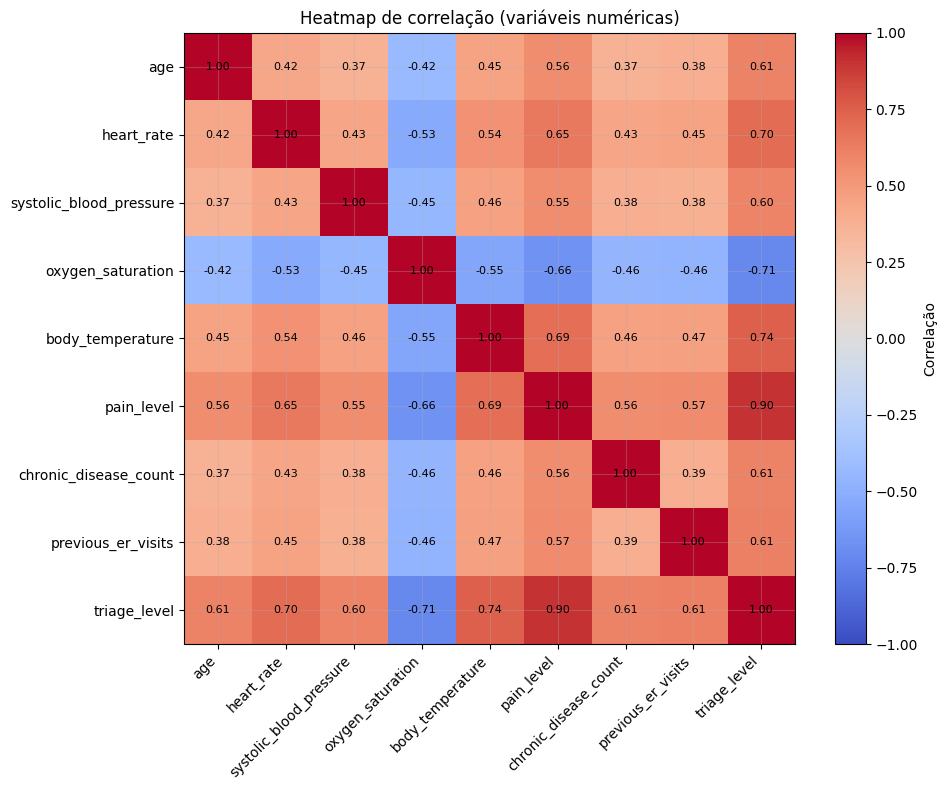

Correlações com triage_level (ordem decrescente):


,correlacao_com_target
pain_level,0.901481
body_temperature,0.744840
heart_rate,0.698281
previous_er_visits,0.612760
age,0.607368
chronic_disease_count,0.605720
systolic_blood_pressure,0.600663
oxygen_saturation,-0.714006


In [68]:
TARGET = "triage_level"

# Correlação apenas entre variaveis numericas
corr_matrix = df.select_dtypes(include=["number"]).corr()

# Reordenar para deixar target ao final (facilita leitura visual)
ordered_cols = [c for c in corr_matrix.columns if c != TARGET] + [TARGET]
corr_matrix = corr_matrix.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)

# Eixos e labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Heatmap de correlação (variáveis numéricas)")

# Barra de cor
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlação")

# Inserir valores de correlação nas células
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()

# Tabela ordenada de correlação com a variável alvo
corr_target = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlações com triage_level (ordem decrescente):")
display(corr_target.to_frame("correlacao_com_target"))

### Interpretação do heatmap de correlação

**Padrões identificados:**
- **`pain_level` (0,90)** é a variável numérica com maior associação linear ao `triage_level` — quanto maior a dor reportada, maior tende a ser a gravidade atribuída na triagem.
- **`oxygen_saturation` (−0,71)** apresenta correlação negativa forte: saturação mais baixa acompanha níveis de triagem mais altos, coerente com instabilidade respiratória em casos graves.
- **`body_temperature` (0,74)**, **`heart_rate` (0,70)** e **`systolic_blood_pressure` (0,60)** sobem junto com a gravidade, indicando resposta fisiológica de estresse.
- **`age` (0,61)**, **`chronic_disease_count` (0,61)** e **`previous_er_visits` (0,61)** também se associam ao target, sugerindo que perfil demográfico e histórico clínico contribuem para a classificação de risco.

**O que isso indica sobre os dados:** o dataset foi construído de forma **coerente com a lógica clínica de triagem** — sinais vitais alterados, dor elevada e comorbidades acompanham casos mais graves. Porém, como `pain_level` domina as demais correlações, modelos podem **depender demais da escala subjetiva de dor** se não forem avaliados por classe.

## 9) Gráficos exploratórios com matplotlib

Nesta seção montamos os gráficos **por partes**. Antes de cada gráfico há um bloco explicando **o que** ele mostra; **logo após a execução**, uma célula de **interpretação** descreve os padrões observados nos dados e o que eles indicam para a triagem.

Definimos um estilo básico (tamanho da figura e grade leve).

In [69]:

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

### 9.1) Distribuição dos níveis de triagem (`triage_level`)

O campo `triage_level` é a **classe alvo**: representa a gravidade atribuída na triagem (valores de 0 a 3 neste dataset). O gráfico de barras abaixo conta **quantos casos** existem em cada nível.

Isso é importante para avaliar o **balanceamento dos atributos**.
No dataset escolhido temos muitos exemplos de "casos leves", ao utilizar métricas de acurácia, podemos ter uma análise propensa a erro.

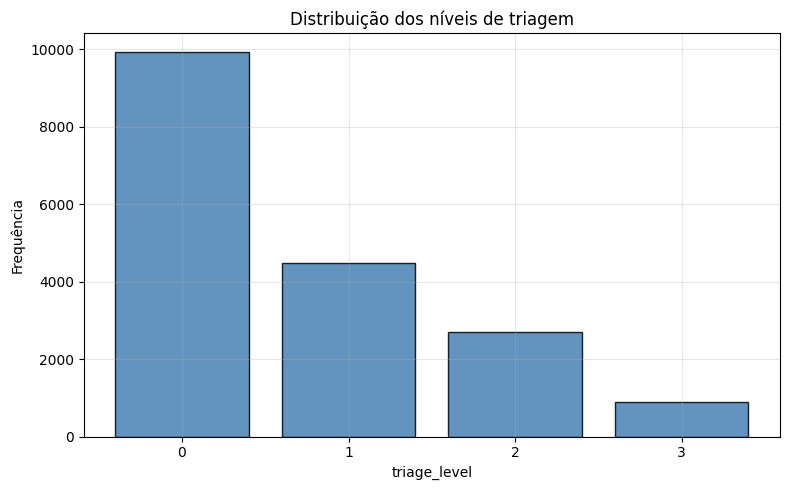

In [70]:
fig, ax = plt.subplots(figsize=(8, 5))
triage_counts = df["triage_level"].value_counts().sort_index()
ax.bar(
    triage_counts.index.astype(str),
    triage_counts.values,
    color="steelblue",
    edgecolor="black",
    alpha=0.85,
)
ax.set_title("Distribuição dos níveis de triagem")
ax.set_xlabel("triage_level")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

### Interpretação — distribuição dos níveis de triagem

**Padrões identificados:**
- O nível **0 concentra 55,1%** dos casos (9.924 registros), enquanto o nível **3 representa apenas 5,0%** (891 casos).
- A curva decresce de forma acentuada: níveis 1 e 2 ficam no meio (24,9% e 15,0%, respectivamente), formando uma **distribuição fortemente assimétrica** em favor de casos leves.

**O que isso indica:** trata-se de um dataset **desbalanceado**, típico de pronto-socorro onde a maioria dos atendimentos é de baixa urgência. Métricas como acurácia global tendem a **superestimar** o desempenho se o modelo aprender a prever predominantemente a classe 0 — daí a necessidade de SMOTE e avaliação por classe (precisão, revocação, F1) na etapa de modelagem.

### 9.2) Modo de chegada (`arrival_mode`)

Este gráfico mostra **como o paciente chegou** ao atendimento (por exemplo `walk_in`, `ambulance` ou `wheelchair`). O tamanho de cada barra é o número de registros naquela categoria.

É útil porque o **modo de chegada** pode estar ligado à gravidade: chegadas por ambulância, por exemplo, costumam concentrar casos mais urgentes. Isso ajuda a contextualizar o dataset antes de modelar ou de comparar grupos.

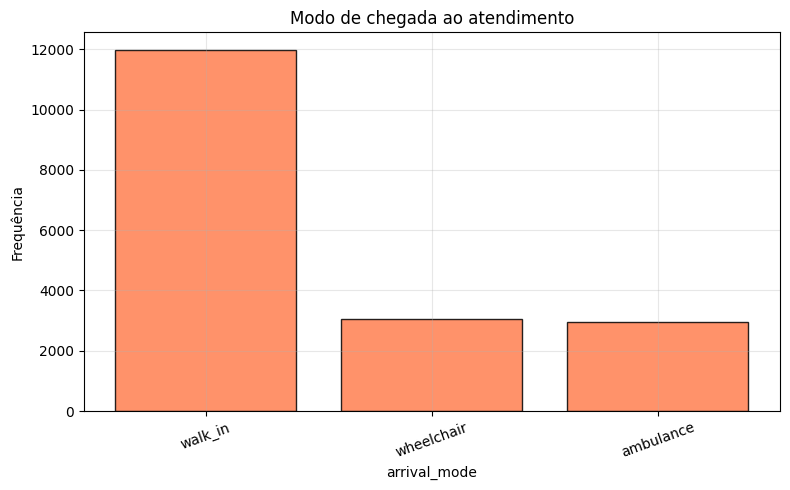

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))
arrival = df["arrival_mode"].value_counts()
ax.bar(arrival.index, arrival.values, color="coral", edgecolor="black", alpha=0.85)
ax.set_title("Modo de chegada ao atendimento")
ax.set_xlabel("arrival_mode")
ax.set_ylabel("Frequência")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Interpretação — modo de chegada

**Padrões identificados:**
- **`walk_in` domina** com cerca de 11.963 casos (~66% do total), seguido por **`wheelchair`** (~3.067) e **`ambulance`** (~2.970) em proporções semelhantes entre si.
- Ambulância e cadeira de rodas juntas representam ~34% dos registros — volume suficiente para analisar diferenças de gravidade entre modos, mas ainda minoritário frente à chegada espontânea.

**O que isso indica:** o dataset reflete um fluxo realista de PS, onde a maior parte chega por conta própria. Qualquer análise ou modelo que use `arrival_mode` deve considerar que **walk_in será a categoria mais frequente** e que ambulância, embora menos numerosa, pode concentrar casos mais graves (investigado na seção 10.1).

### 9.3) Distribuição etária (`age`)

O **histograma** resume como as idades se distribuem no conjunto: onde há mais concentração e se existem caudas (muito jovem ou muito idoso).

Serve para verificar se o dataset **possui faixas etárias diversificadas**. Um recorte muito enviesado em idade pode afetar a interpretação de risco e a generalização de qualquer modelo de triagem treinado nesses dados.

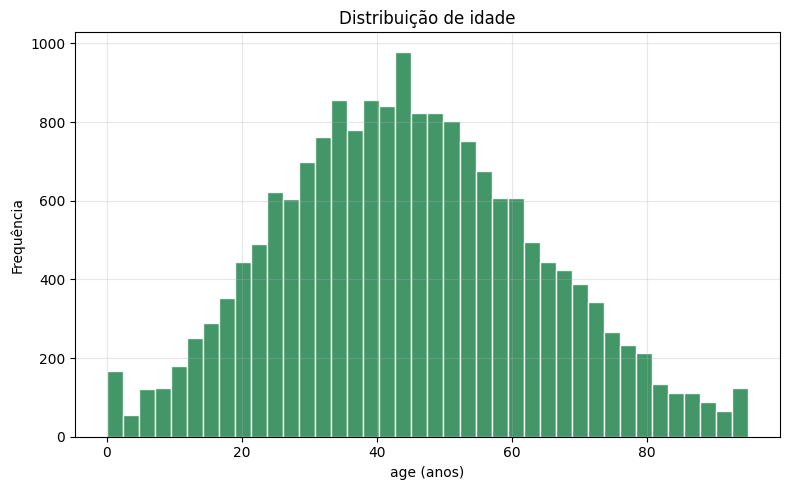

In [72]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["age"], bins=40, color="seagreen", edgecolor="white", alpha=0.9)
ax.set_title("Distribuição de idade")
ax.set_xlabel("age (anos)")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

### Interpretação — distribuição etária

**Padrões identificados:**
- Idades variam de **0 a 95 anos**, com **média e mediana próximas de 44–45 anos**, sugerindo cobertura ampla de adultos e idosos sem concentração extrema em um único pico.
- O histograma tende a ser **relativamente uniforme** na faixa adulta (aprox. 20–70 anos), com caudas em extremos etários mais finas.

**O que isso indica:** há **diversidade etária** suficiente para treinar e testar generalização por idade, mas a análise por faixas (seção 10.5) mostrará que a **proporção de gravidade muda muito** conforme a idade — ou seja, a distribuição etária é equilibrada, mas o risco **não** é homogêneo entre faixas.

### 9.4) Distribuicao do nível de dor (`pain_level`)

A **escala de dor** é um dos sinais subjetivos mais usados na triagem. O histograma indica com que frequência aparecem cada valor de `pain_level` no dataset.

Comparar esta forma com o `triage_level` (e com o heatmap de correlação já visto) ajuda a entender se dor mais alta **acompanha** niveis de gravidade mais altos de forma consistente nos dados.

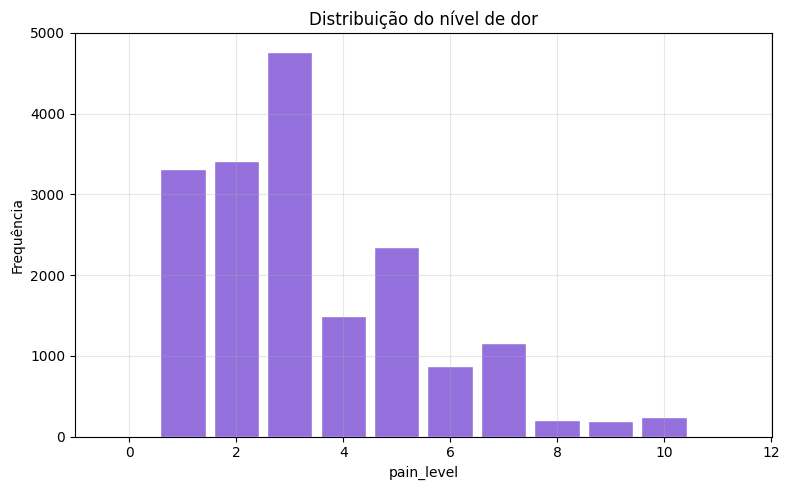

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(
    df["pain_level"],
    bins=range(0, 13),
    align="left",
    rwidth=0.85,
    color="mediumpurple",
    edgecolor="white",
)
ax.set_title("Distribuição do nível de dor")
ax.set_xlabel("pain_level")
ax.set_ylabel("Frequência")
plt.tight_layout()
plt.show()

### Interpretação — nível de dor

**Padrões identificados:**
- Valores baixos de dor (**1 a 3**) concentram a maior parte das frequências (milhares de casos em cada nível), refletindo o predomínio de triagens leves.
- Há uma **segunda concentração** em torno de dor 5–7 e valores altos (8–10) são menos frequentes, mas presentes — compatível com a cauda de casos graves do dataset.

**O que isso indica:** a escala de dor **varia de forma ampla** e não está limitada a um único valor, o que a torna informativa para o modelo. A forma do histograma reforça o desbalanceamento geral (muitos casos leves, poucos com dor extrema), alinhado ao heatmap onde `pain_level` é o preditor numérico mais forte.

### 9.5) Sinais vitais por nível de triagem (boxplot)

Aqui comparamos **três medidas numericas** entre grupos definidos pelo `triage_level`: frequência cardiaca, saturação de oxigênio e temperatura corporal.

Cada **boxplot** resume mediana, quartis e valores extremos daquele sinal **dentro de cada nivel de triagem**. Assim vemos nao so tendencias de media, mas dispersao e possiveis outliers — um complemento util ao heatmap de correlacao, que so captura relacao linear entre numeros.

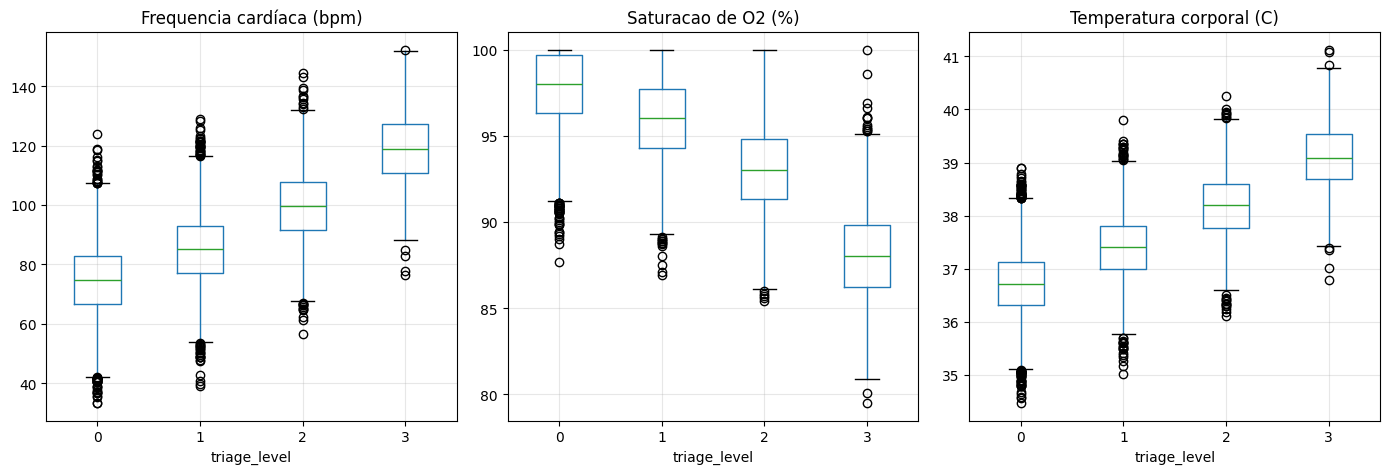

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
box_cols = ["heart_rate", "oxygen_saturation", "body_temperature"]
titles_pt = {
    "heart_rate": "Frequencia cardíaca (bpm)",
    "oxygen_saturation": "Saturacao de O2 (%)",
    "body_temperature": "Temperatura corporal (C)",
}
for ax, col in zip(axes, box_cols):
    df.boxplot(column=col, by="triage_level", ax=ax)
    ax.set_title(titles_pt[col])
    ax.set_xlabel("triage_level")
plt.suptitle("")
plt.tight_layout()
plt.show()

### Interpretação — sinais vitais por nível de triagem (boxplot)

**Padrões identificados:**
- **Frequência cardíaca:** mediana e dispersão **aumentam** do nível 0 (~75 bpm em média) ao nível 3 (~119 bpm), com caixas progressivamente deslocadas para cima.
- **Saturação de O₂:** comportamento **inverso** — mediana cai de ~97,7% (nível 0) para ~88,1% (nível 3), com mais outliers em saturações baixas nos níveis altos.
- **Temperatura corporal:** mediana sobe de ~36,7 °C para ~39,1 °C conforme a gravidade, indicando febre/hipertermia associada a casos mais urgentes.

**O que isso indica:** os sinais vitais **se separam visualmente entre classes de triagem**, validando que o target reflete alterações fisiológicas mensuráveis — não apenas a dor subjetiva. A sobreposição entre caixas adjacentes (ex.: níveis 1 e 2) sugere que o modelo precisará combinar **várias features** para discriminar classes intermediárias.

### 9.6) Dor versus frequência cardíaca (grafico de dispersão)

Cada **ponto** é um paciente: no eixo horizontal está o `pain_level` e na vertical a `heart_rate`. A **cor** do ponto indica o `triage_level`.

Usamos transparência (`alpha`) para onde há **muitos pontos sobrepostos** parecer mais “denso”. O objetivo é visualizar, de forma conjunta, se combinações de dor alta e FC elevada aparecem mais nos níveis de triagem mais graves — algo que a análise de correlação já sugere, mas aqui fica **geometricamente** visível.

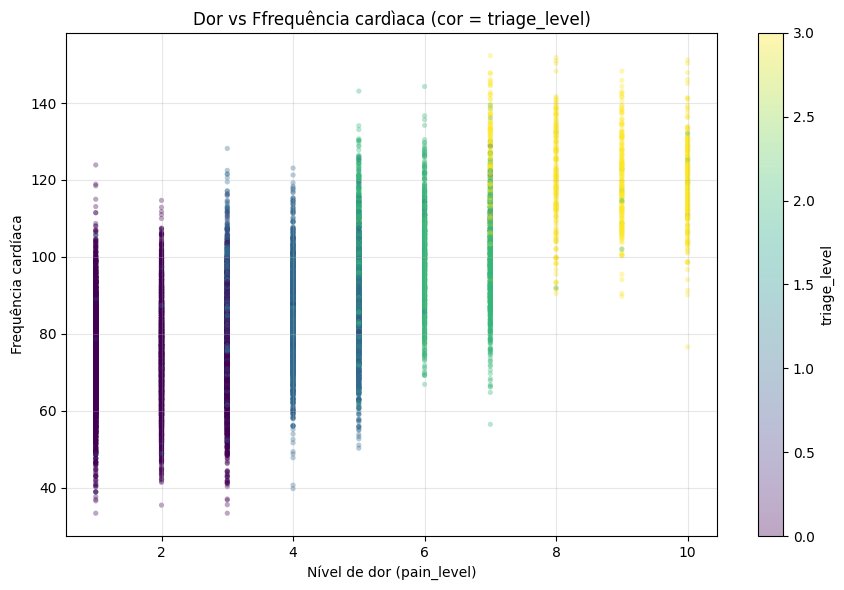

In [75]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    df["pain_level"],
    df["heart_rate"],
    c=df["triage_level"],
    cmap="viridis",
    alpha=0.35,
    s=14,
    edgecolors="none",
)
ax.set_xlabel("Nível de dor (pain_level)")
ax.set_ylabel("Frequência cardíaca")
ax.set_title("Dor vs Ffrequência cardìaca (cor = triage_level)")
cb = fig.colorbar(sc, ax=ax)
cb.set_label("triage_level")
plt.tight_layout()
plt.show()

### Interpretação — dor vs frequência cardíaca

**Padrões identificados:**
- Pontos com **dor baixa e FC moderada** (canto inferior esquerdo) aparecem majoritariamente nas cores do **nível 0** (verde/amarelo escuro no mapa viridis).
- Combinações de **dor alta + FC elevada** concentram-se nas cores do **nível 2 e 3** (amarelo claro/verde claro), formando uma nuvem deslocada para cima e para a direita.
- Há **sobreposição** entre classes no meio do gráfico (dor 3–6, FC 80–100 bpm), onde vários níveis de triagem coexistem.

**O que isso indica:** dor e FC **juntas** ajudam a separar extremos (casos leves vs graves), mas isoladamente não bastam para classificar os casos intermediários — reforçando a utilidade de incluir pressão arterial, SpO₂, temperatura e histórico clínico no modelo.

### 9.7) Medias de sinais vitais por nível de triagem (barras)

Por fim, três gráficos de barras lado a lado mostram a **média** de frequência cardíaca, pressão arterial sistólica e saturação de oxigênio **para cada** `triage_level`.

Mantêmos **um subplot por variável** porque as unidades e faixas típicas são diferentes: juntar tudo num único eixo distorceria a comparação. A leitura desejada é: “ao subir o nível de triagem, essas médias tendem a subir ou cair?” — em linha com o que já observamos nos boxplots e na correlação.

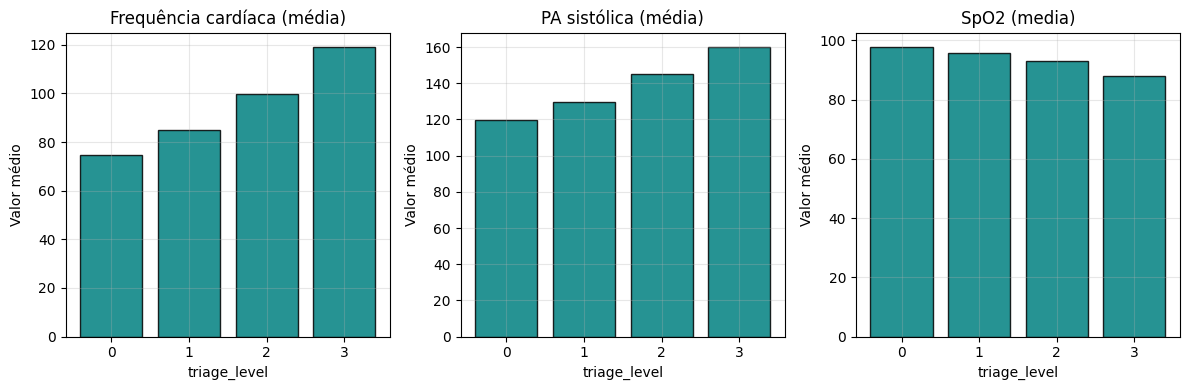

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
bar_specs = [
    ("heart_rate", "Frequência cardíaca (média)"),
    ("systolic_blood_pressure", "PA sistólica (média)"),
    ("oxygen_saturation", "SpO2 (media)"),
]
for ax, (col, title) in zip(axes, bar_specs):
    m = df.groupby("triage_level")[col].mean()
    ax.bar(m.index.astype(str), m.values, color="teal", edgecolor="black", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel("triage_level")
    ax.set_ylabel("Valor médio")
plt.tight_layout()
plt.show()

### Interpretação — médias de sinais vitais por triagem

**Padrões identificados:**
- **FC, PA sistólica e SpO₂** seguem tendências **monotônicas** ao longo dos níveis 0→3:
  - FC: 74,9 → 119,0 bpm
  - PA sistólica: 119,9 → 159,9 mmHg
  - SpO₂: 97,7 → 88,1 % (queda)
- O salto entre níveis **2 e 3** é mais pronunciado em FC e PA, enquanto a queda de SpO₂ é gradual mas contínua.

**O que isso indica:** a gravidade de triagem no dataset está **graduada de forma consistente** nos sinais vitais — útil para justificar a escala ordinal 0–3 como target. As barras confirmam visualmente o que o heatmap quantificou por correlação.

### 10.1) Pergunta: o modo de chegada associa-se a gravidade na triagem?

**Por que perguntamos:** em pronto-socorro, ambulância costuma transportar casos pré-selecionados como urgentes; se o dataset refletir isso, `arrival_mode` é feature relevante e ajuda a validar a qualidade dos dados.

**Como respondemos:** empilhamos, para cada modo de chegada, a proporção (%) de casos em cada `triage_level`. A interpretação numérica está na célula logo abaixo do gráfico.

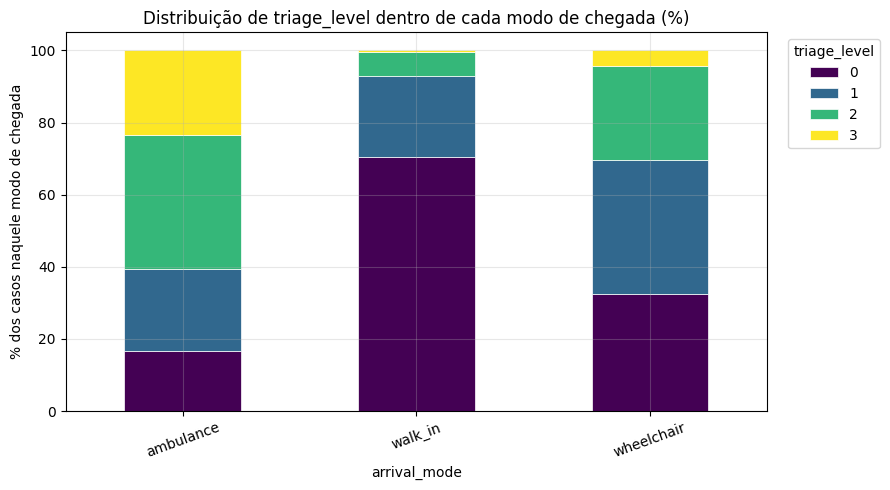

In [77]:
ct = pd.crosstab(df["arrival_mode"], df["triage_level"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct.plot(kind="bar", stacked=True, ax=ax, colormap="viridis", edgecolor="white", linewidth=0.5)
ax.set_title("Distribuição de triage_level dentro de cada modo de chegada (%)")
ax.set_xlabel("arrival_mode")
ax.set_ylabel("% dos casos naquele modo de chegada")
ax.legend(title="triage_level", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Resposta à pergunta 10.1 — o modo de chegada associa-se à gravidade?

**Sim, a associação é clara e segue a lógica operacional do pronto-socorro:**

| Modo de chegada | % nível 0 (leve) | % nível 3 (grave) |
|---|---|---|
| **walk_in** | **70,5%** | **0,4%** |
| **wheelchair** | 32,4% | 4,5% |
| **ambulance** | 16,8% | **23,6%** |

- Pacientes que chegam **de ambulância** têm a menor fração de casos leves (16,8%) e a **maior concentração de nível 3** (23,6%) — quase **60× mais** casos graves que walk_in (0,4%).
- **Walk_in** concentra casos leves: mais de **7 em cada 10** atendimentos são nível 0.
- **Wheelchair** ocupa posição intermediária, com perfil de gravidade entre os dois extremos.

**Conclusão:** `arrival_mode` é um **indicador operacional válido** de gravidade neste dataset e deve entrar no modelo (via encoding). Também justifica **estratificar** a avaliação do classificador por modo de chegada, pois o desempenho pode variar entre fluxos distintos.

### 10.4) Pergunta: o nível de dor aumenta sistematicamente com o triage_level?

**Por que perguntamos:** dor é um dos principais critérios de triagem (ex.: protocolos Manchester/ESI); se não houver relação monotônica com `triage_level`, o target ou a escala de dor pode estar inconsistente.

**Como respondemos:** boxplot de `pain_level` **dentro de cada** nível de triagem (mediana, quartis e outliers). A leitura quantitativa está na célula abaixo do gráfico.

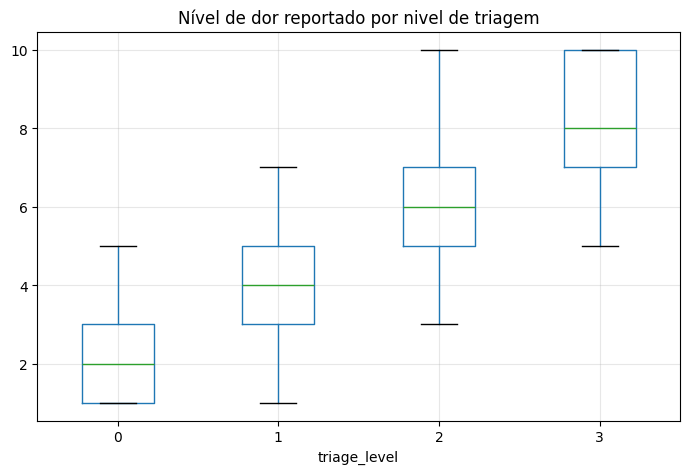

In [78]:
fig, ax = plt.subplots(figsize=(7, 5))
df.boxplot(column="pain_level", by="triage_level", ax=ax)
ax.set_title("Nível de dor reportado por nivel de triagem")
ax.set_xlabel("triage_level")
plt.suptitle("")
plt.tight_layout()
plt.show()

### Resposta à pergunta 10.4 — o nível de dor aumenta sistematicamente com o triage_level?

**Sim. A relação é quase linear e muito consistente:**

| triage_level | Mediana de dor | Média de dor |
|---|---|---|
| 0 | 2 | 2,0 |
| 1 | 4 | 3,9 |
| 2 | 6 | 6,0 |
| 3 | 8 | 8,4 |

- Cada incremento no nível de triagem desloca a **mediana de dor em ~2 pontos** na escala.
- As caixas do boxplot ficam **pouco sobrepostas** entre níveis adjacentes: a mediana do nível 1 (4) já fica acima do terceiro quartil típico do nível 0 (~2–3).
- No nível 3, a dispersão é um pouco maior (desvio ~1,2), refletindo casos graves com dor variável, mas a mediana permanece alta (8).

**Conclusão:** `pain_level` é o **sinal mais discriminante** entre classes de triagem — coerente com a correlação de 0,90 no heatmap. O modelo provavelmente usará dor como feature central, mas isso também exige cuidado: dor é **subjetiva** e pode ser reportada de forma inconsistente na prática clínica real.

### 10.5) Pergunta: a mistura de gravidades é semelhante entre faixas etárias?

**Por que perguntamos:** idosos tendem a apresentar quadros mais graves na triagem real; se todas as faixas tivessem a mesma proporção de nível 3, o dataset poderia não refletir essa realidade clínica.

**Como respondemos:** barras empilhadas com a composição percentual de `triage_level` em cada faixa (<30, 30–49, 50–69, 70+). A interpretação detalhada está na célula abaixo do gráfico.

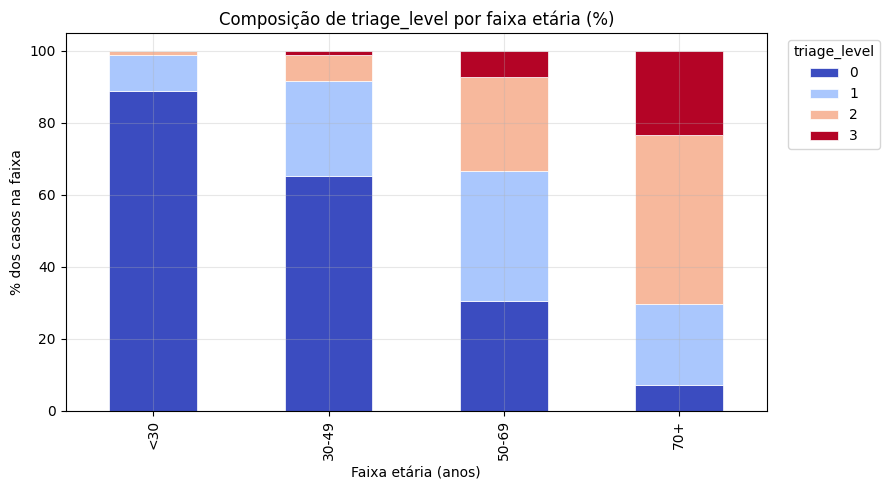

In [79]:
age_group = pd.cut(
    df["age"],
    bins=[0, 30, 50, 70, 200],
    labels=["<30", "30-49", "50-69", "70+"],
    include_lowest=True,
)
ct_age = pd.crosstab(age_group, df["triage_level"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(9, 5))
ct_age.plot(kind="bar", stacked=True, ax=ax, colormap="coolwarm", edgecolor="white", linewidth=0.5)
ax.set_title("Composição de triage_level por faixa etária (%)")
ax.set_xlabel("Faixa etária (anos)")
ax.set_ylabel("% dos casos na faixa")
ax.legend(title="triage_level", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Resposta à pergunta 10.5 — a mistura de gravidades é semelhante entre faixas etárias?

**Não. A composição de gravidade muda drasticamente com a idade:**

| Faixa etária | % nível 0 | % nível 2 | % nível 3 |
|---|---|---|---|
| **< 30 anos** | **88,7%** | 1,0% | 0,0% |
| **30–49** | 65,3% | 7,1% | 1,2% |
| **50–69** | 30,5% | 25,9% | 7,4% |
| **70+** | 7,2% | 46,8% | **23,5%** |

- Jovens (< 30) são **quase exclusivamente** casos leves: quase 9 em 10 atendimentos são nível 0 e **nenhum** caso de nível 3 na amostra.
- Idosos (70+) invertem o padrão: apenas **7,2%** são leves, enquanto **~70%** caem nos níveis 2 e 3 combinados.
- A faixa 50–69 funciona como **zona de transição**, com mix mais equilibrado entre leve e moderado/grave.

**Conclusão:** existe **viés etário forte** na distribuição de gravidade — idade avançada acompanha risco mais alto neste dataset. Modelos de triagem devem ser avaliados **por faixa etária** para garantir que não subestimem gravidade em idosos nem superestimem em jovens. Também reforça incluir `age` como feature relevante.

### 10.6) Encoding da coluna `arrival_mode`

Como este campo é importante e deve ser levado em consideração, foi necessário tratá-lo para que o modelo o compreenda tendo em visa que modelos de IA só compreendem valores numéricos.


In [80]:
label_encoder = LabelEncoder()

mapping = {'walk_in': 0, 'wheelchair': 1, 'ambulance': 2}
df['arrival_mode_label_encoding'] = df['arrival_mode'].map(mapping)

df.head()


,age,heart_rate,systolic_blood_pressure,oxygen_saturation,body_temperature,pain_level,chronic_disease_count,previous_er_visits,arrival_mode,triage_level,arrival_mode_label_encoding
0,17.9,95.4,147.1,97.4,36.48,1,0,0,walk_in,0,0
1,79.2,147.9,158.6,96.0,39.35,10,4,2,ambulance,3,2
2,51.1,87.1,128.2,98.5,37.74,5,2,2,walk_in,1,0
3,56.8,84.7,147.2,92.5,37.55,4,4,4,walk_in,1,0
4,39.2,58.0,107.8,99.0,36.26,2,1,1,walk_in,0,0


### 10.6b) Heatmap de correlação incluindo `arrival_mode_label_encoding`

Após o encoding ordinal (`walk_in=0`, `wheelchair=1`, `ambulance=2`), incluímos `arrival_mode_label_encoding` na matriz de **correlação de Pearson** junto com as demais variáveis numéricas.

**Como ler:** trata-se de uma aproximação **linear** entre categorias codificadas como inteiros — útil para associação monotônica, sabendo que a distância 0→1→2 não representa intervalos clínicos iguais entre modos.

A interpretação dos padrões observados está na célula logo abaixo do gráfico.

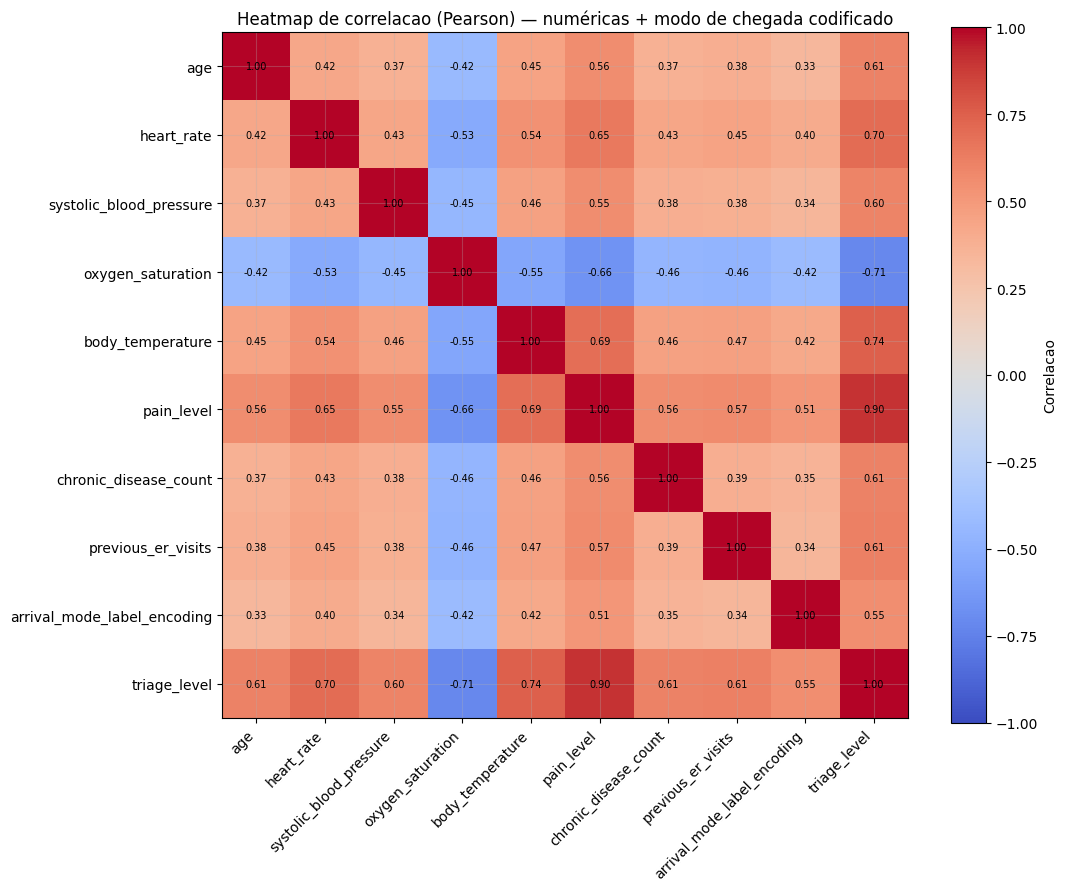

Correlacao Pearson entre `arrival_mode_label_encoding` e `triage_level`: 0.5517


In [81]:
TARGET = "triage_level"
ENC_COL = "arrival_mode_label_encoding"

# Todas as colunas numéricas (apos encoding 11.6, inclui modo de chegada codificado)
corr_am = df.select_dtypes(include=["number"]).corr()

ordered_cols = [c for c in corr_am.columns if c != TARGET] + [TARGET]
corr_am = corr_am.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_am.values, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_am.columns)))
ax.set_yticks(range(len(corr_am.index)))
ax.set_xticklabels(corr_am.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_am.index)
ax.set_title("Heatmap de correlacao (Pearson) — numéricas + modo de chegada codificado")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Correlacao")

for i in range(corr_am.shape[0]):
    for j in range(corr_am.shape[1]):
        val = corr_am.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black", fontsize=7)

plt.tight_layout()
plt.show()

if ENC_COL in corr_am.index and TARGET in corr_am.columns:
    r_enc_target = corr_am.loc[ENC_COL, TARGET]
    print(f"Correlacao Pearson entre `{ENC_COL}` e `{TARGET}`: {r_enc_target:.4f}")
else:
    print(f"Coluna `{ENC_COL}` ausente — rode primeiro a célula de encoding 11.6.")


### Interpretação — heatmap com `arrival_mode_label_encoding`

**Padrão principal identificado:**
- **`arrival_mode_label_encoding` ↔ `triage_level`: 0,55** — terceira maior associação linear com o target, atrás apenas de `pain_level` (0,90) e `body_temperature` (0,74) entre as relações diretas com a gravidade.
- O sinal **positivo** confirma a seção 10.1: códigos mais altos (ambulância = 2) acompanham triagens mais graves.

**Comparação com o heatmap da seção 8 (sem encoding):**
- Incluir o modo de chegada **não altera** o ranking das demais variáveis — `pain_level` e sinais vitais permanecem no topo.
- `arrival_mode_label_encoding` entra como feature **relevante, porém secundária** frente a dor e vitais — coerente com a importância ~1,7% no Random Forest (seção 12.1).

**O que isso indica:**
- Vale **manter** `arrival_mode_label_encoding` no modelo (informação operacional real), mas **não substituir** sinais clínicos diretos.
- A correlação 0,55 justifica o encoding escolhido; alternativas como one-hot poderiam capturar não-linearidades, mas o ganho provavelmente seria marginal neste dataset sintético.

### 10.7) Padronização do `oxygen_saturation`

Na limpeza (secao 7.1), `oxygen_saturation` e limitada a [0, 100] por plausibilidade clínica.


### 10.8) Histogramas das variáveis por nível de triagem

Painel de **histogramas sobrepostos**: cada subplot mostra a distribuição de uma feature numérica, com barras **coloridas por `triage_level`** (0 a 3). Permite ver, num único olhar, se as distribuições se separam entre classes — complemento visual ao heatmap (correlação) e aos boxplots (seção 9.5).

A interpretação dos padrões está na célula logo abaixo do gráfico.

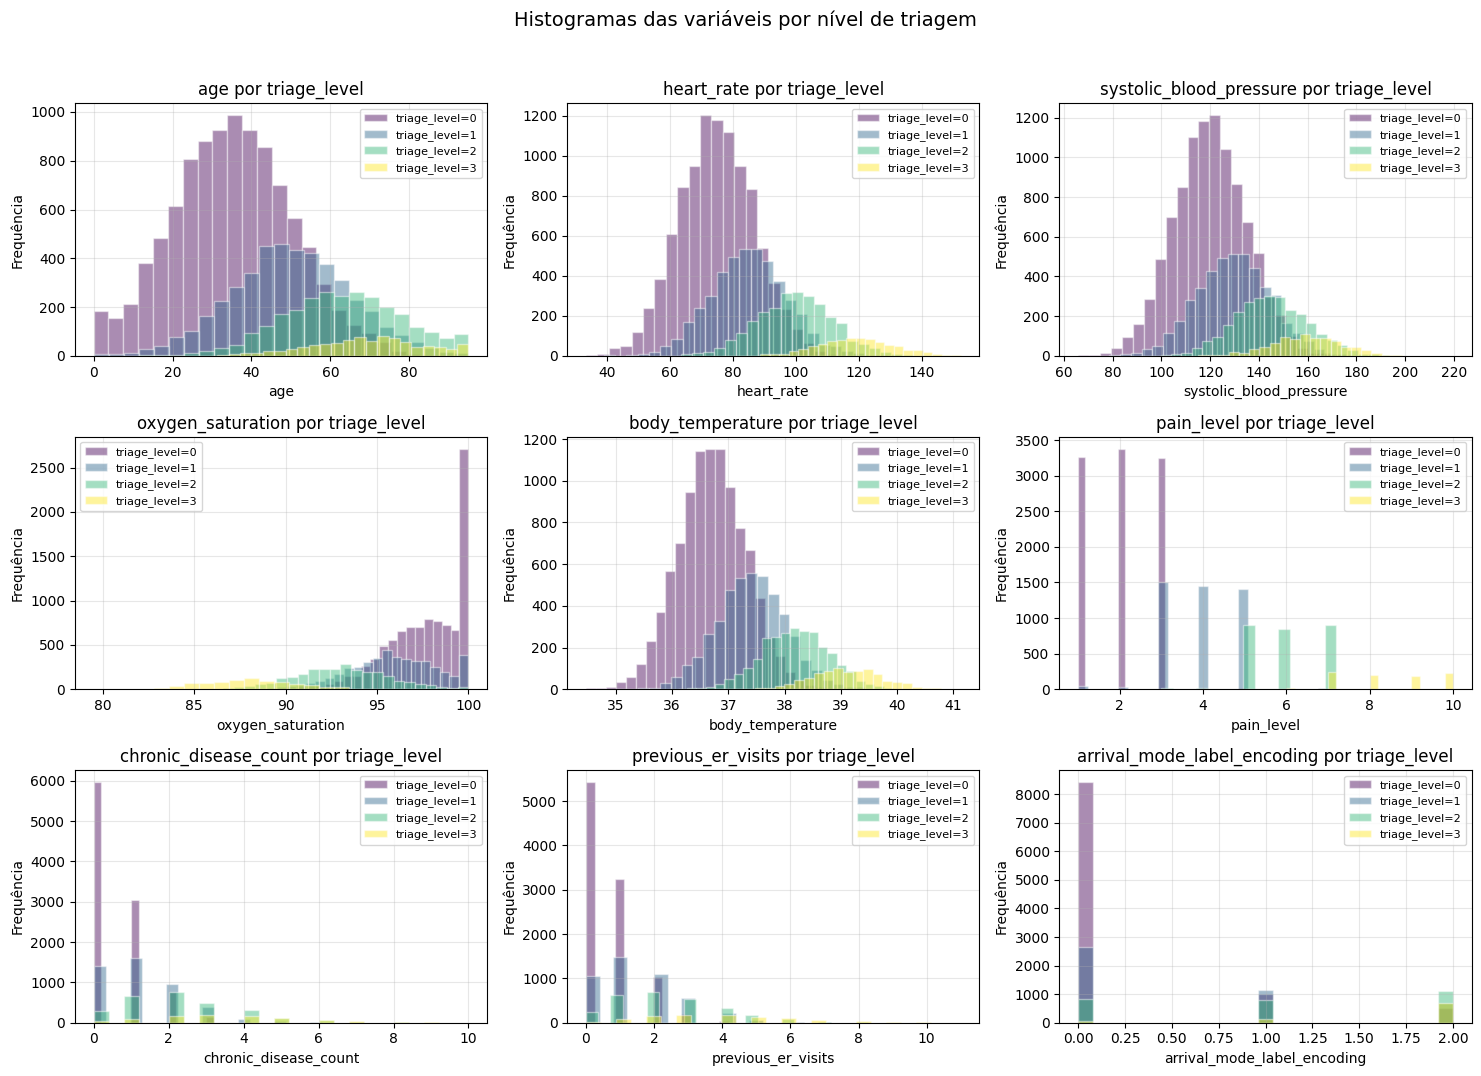

In [82]:
TARGET = "triage_level"

features = [c for c in df.select_dtypes(include=["number"]).columns if c != TARGET]

n = len(features)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

niveis = sorted(df[TARGET].dropna().unique())
cmap = plt.get_cmap("viridis", len(niveis))
cores = {nivel: cmap(i) for i, nivel in enumerate(niveis)}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features):
    ax = axes[i]
    for nivel in niveis:
        valores = df.loc[df[TARGET] == nivel, col].dropna()
        if len(valores) == 0:
            continue
        ax.hist(
            valores,
            bins=25,
            alpha=0.45,
            label=f"triage_level={nivel}",
            color=cores[nivel],
            edgecolor="white",
        )
    ax.set_title(f"{col} por triage_level")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Histogramas das variáveis por nível de triagem", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Interpretação — histogramas por feature e triage_level

**Padrões identificados (separação visual entre cores/níveis):**

| Feature | Padrão no gráfico | Médias por nível (0→3) |
|---|---|---|
| **`pain_level`** | **Separação mais nítida** — picos de histograma deslocam para a direita conforme a gravidade | 2,0 → 3,9 → 6,0 → 8,4 |
| **`body_temperature`** | Distribuições progressivamente deslocadas para temperaturas mais altas | 36,7 → 37,4 → 38,2 → 39,1 °C |
| **`heart_rate`** | Cauda de FC elevada cresce nos níveis 2–3 | 75 → 85 → 100 → 119 bpm |
| **`oxygen_saturation`** | Inversão: nível 0 concentra SpO₂ altas (~98%); nível 3 puxa para baixo (~88%) | 97,7 → 95,9 → 93,0 → 88,1 % |
| **`age`** | Nível 0 concentrado em adultos jovens; nível 3 deslocado para 60–80 anos | 35 → 50 → 63 → 69 anos |
| **`arrival_mode_label_encoding`** | Nível 0 agrupa em códigos baixos (walk_in); nível 3 em códigos altos (ambulância) | 0,2 → 0,6 → 1,1 → 1,7 |
| **`chronic_disease_count`** / **`previous_er_visits`** | Separação moderada — comorbidades e histórico sobem com gravidade | spreads ~2,9 e ~3,3 |

**Sobreposições relevantes:**
- **`systolic_blood_pressure`** e **`heart_rate`** nos níveis **1 e 2** apresentam histogramas parcialmente sobrepostos — explica por que o modelo confunde classes intermediárias (matriz de confusão, seção 12).
- **`pain_level`** também tem alguma sobreposição entre 1↔2, mas bem menor que nas demais features isoladas.

**O que isso indica:**
- O painel **confirma visualmente** o ranking do heatmap: dor e sinais vitais são os eixos que mais separam classes.
- Features demográficas/históricas (`age`, comorbidades, visitas prévias) contribuem, mas com **distribuições mais sobrepostas** — o modelo precisará combiná-las, não confiar em uma só.
- Este gráfico **fecha a EDA**: justifica incluir todas as features numéricas no treino, priorizando dor + vitais na interpretação clínica dos resultados.

### 11) Modelos de treinamento de IA

Nesta etapa iremos treinar o nosso Modelo de IA

### 11.1) Modelo Decision Tree

É um algoritmo de aprendizado supervisionado utilizado para classificação e regressão. Estruturado como uma árvore hierárquica, ele particiona dados recursivamente com base em regras de "if" e "else"

Nesta seção iremos treinar o nosso modelo Utilizando o Decision Tree

In [83]:
# Separando em treino e teste

# tirando arrival_mode por que foi criada a arrival_mode_label_encoding
# dentro do x vamos colocar os atributos que consideramos relevantes após a análise exploratória
x = df.drop(columns=['triage_level', 'arrival_mode'])
# dentro do y colocamos o atributo/classe alvo que é o triage_level
y = df['triage_level'] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=7) 

Acuracia (teste): 0.8783333333333333

Relatório por classe (Decision Tree):
              precision    recall  f1-score   support

     nivel 0     0.9198    0.9647    0.9417      1985
     nivel 1     0.8485    0.6867    0.7591       897
     nivel 2     0.7705    0.8889    0.8255       540
     nivel 3     0.8935    0.8483    0.8703       178

    accuracy                         0.8783      3600
   macro avg     0.8581    0.8472    0.8491      3600
weighted avg     0.8783    0.8783    0.8752      3600



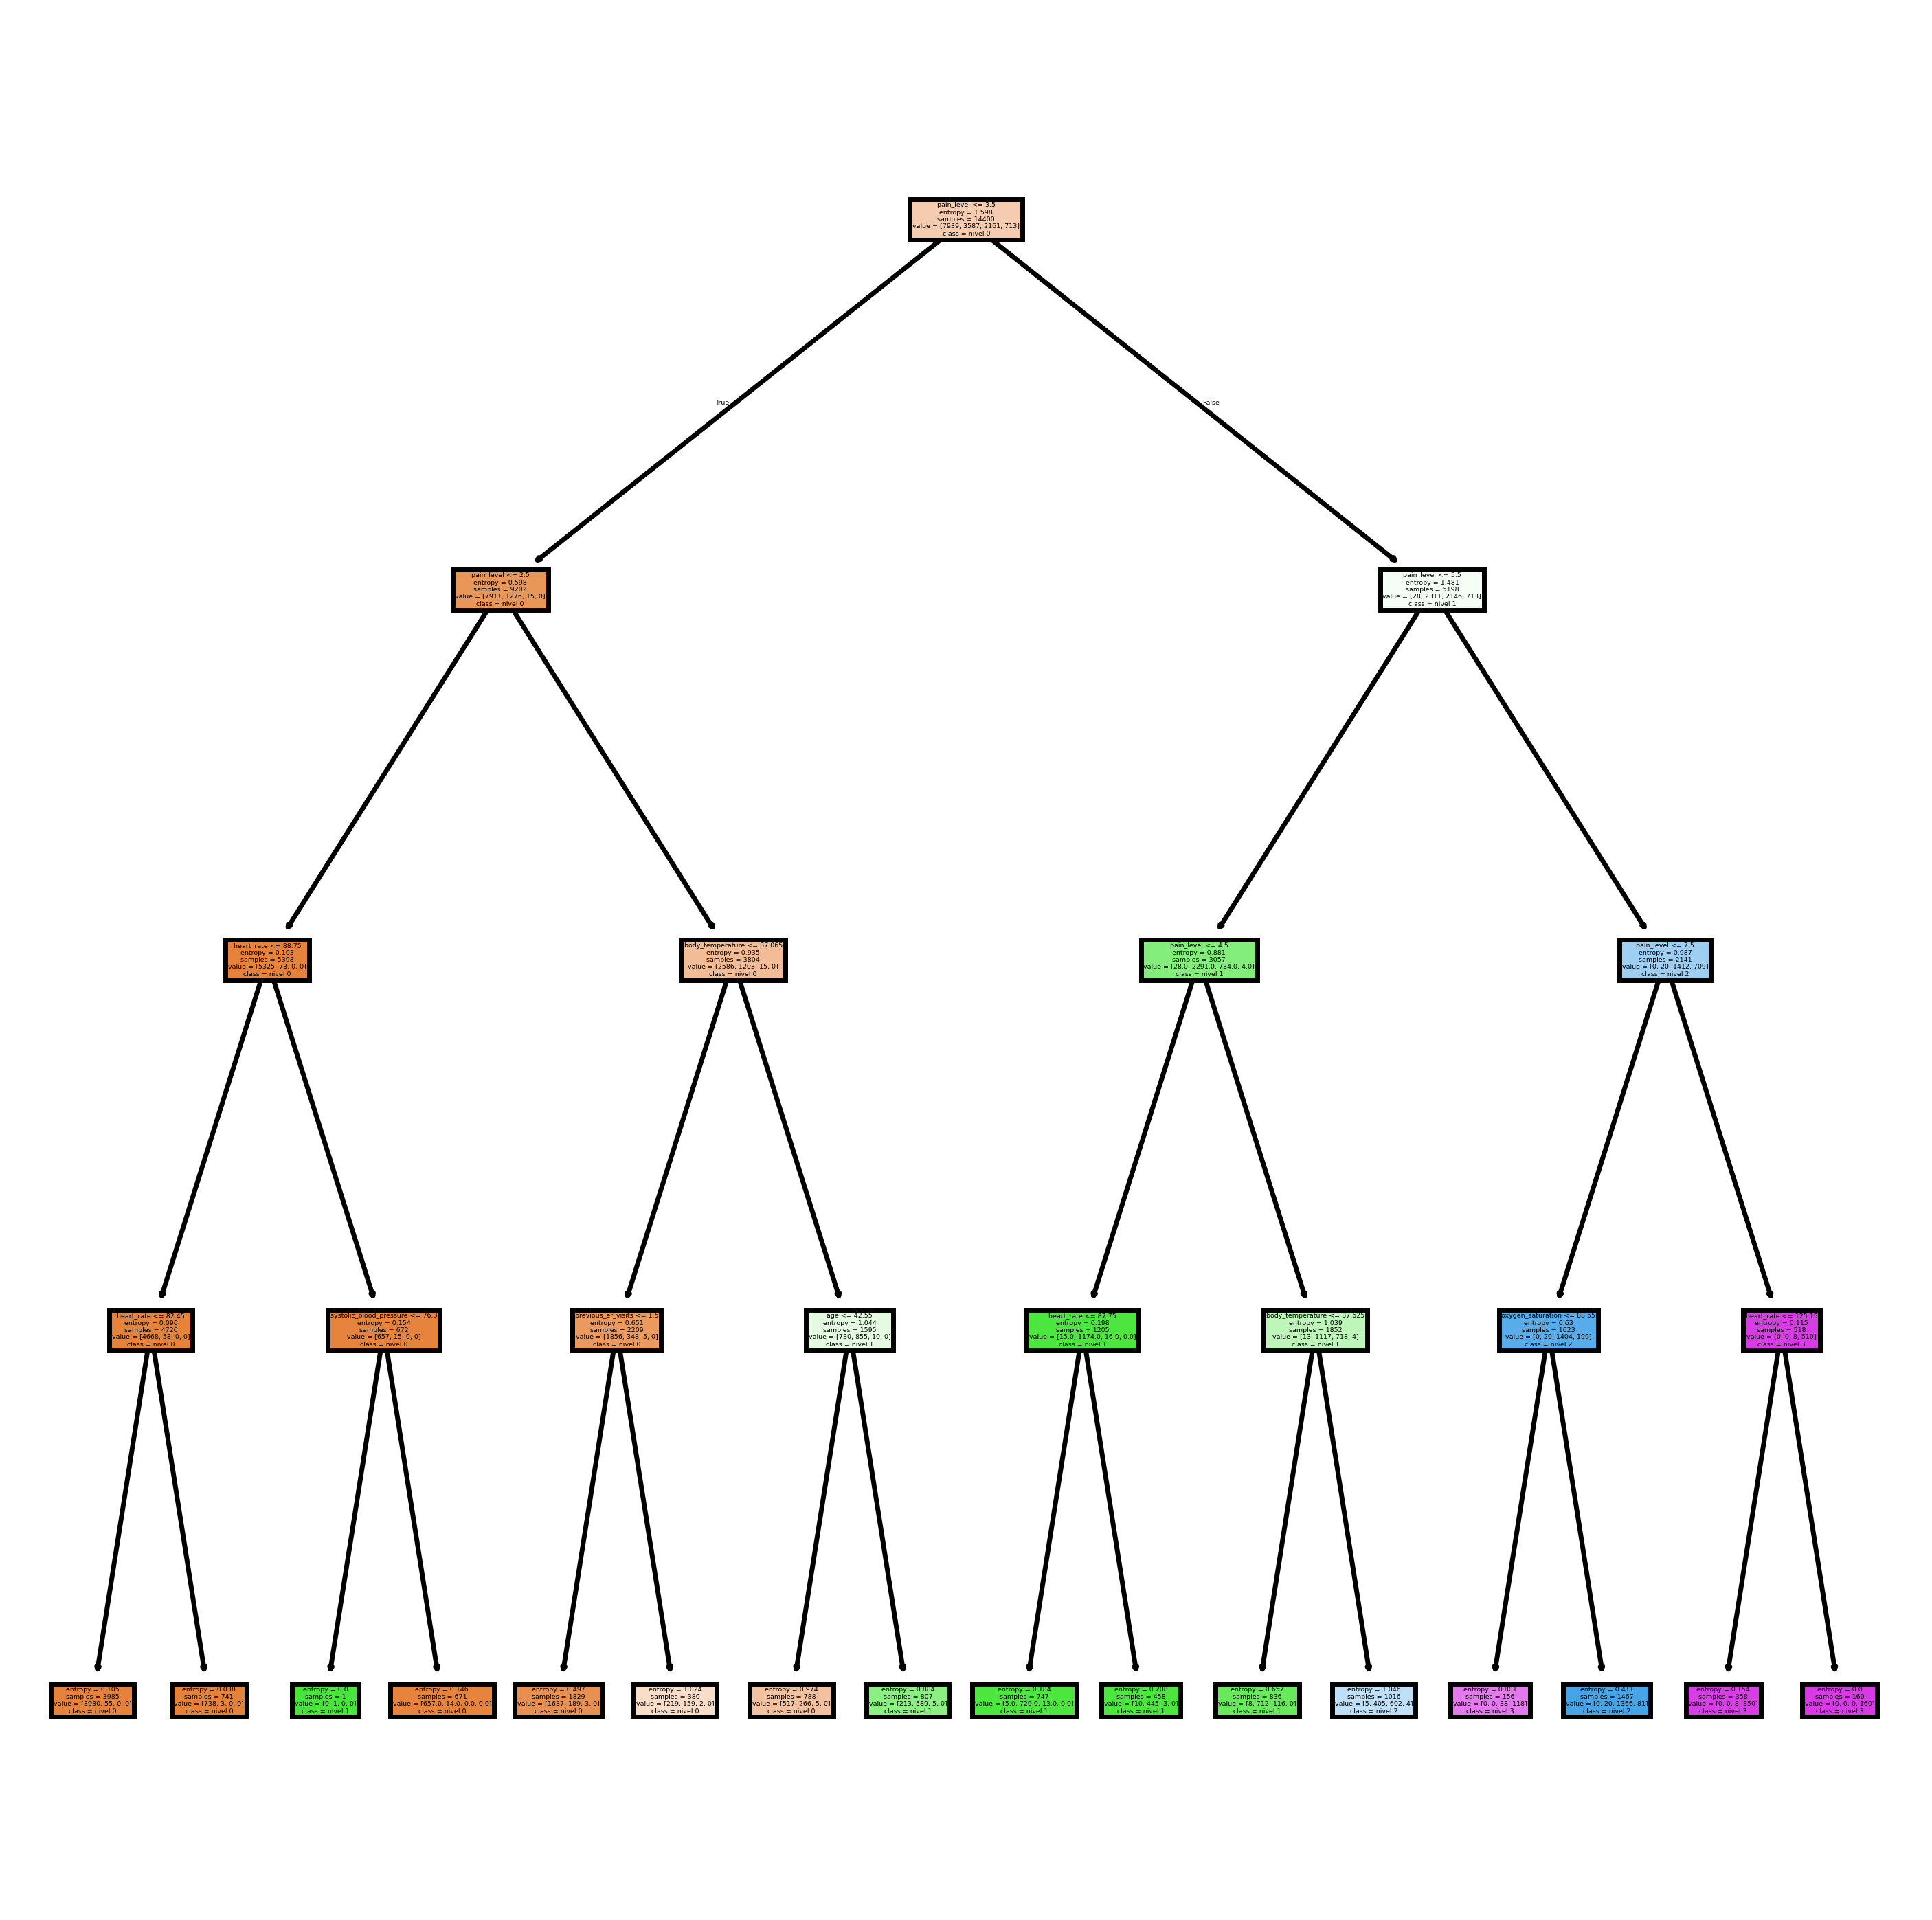

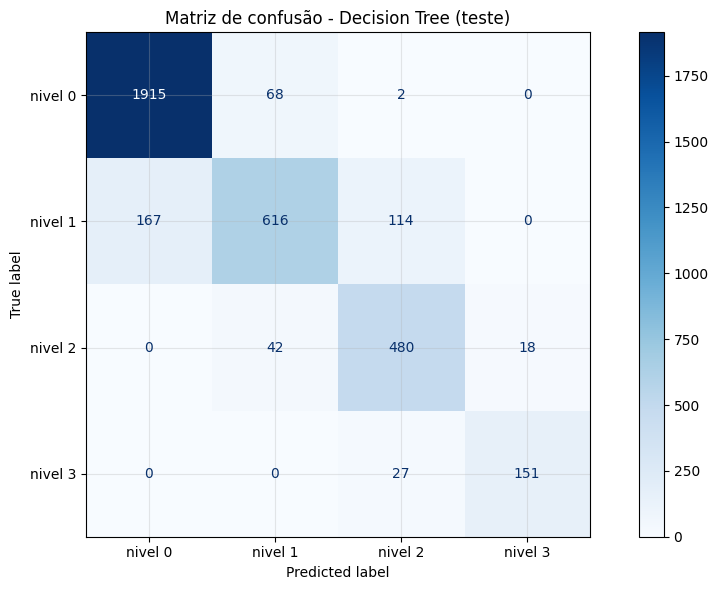

In [84]:
# Criando o modelo de árvore de decisão:
dt = DecisionTreeClassifier(random_state=7, criterion='entropy', max_depth=4)

feature_names = list(x.columns)
class_names = ["nivel 0", "nivel 1", "nivel 2", "nivel 3"]

# Treinando o modelo
dt.fit(x_train, y_train)

# Previsões
y_predito = dt.predict(x_test)

# Métricas treino vs teste
acc_dt_train = dt.score(x_train, y_train)
acc_dt_test = accuracy_score(y_test, y_predito)
print(f"Acurácia (treino): {acc_dt_train:.4f}")
print(f"Acurácia (teste):  {acc_dt_test:.4f}")
print(f"Gap treino-teste:  {acc_dt_train - acc_dt_test:.4f}")
print("\nRelatório por classe (Decision Tree — teste):")
print(classification_report(y_test, y_predito, target_names=class_names, digits=4))

cm_dt = confusion_matrix(y_test, y_predito)
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=class_names).plot(cmap="Blues")
plt.title("Matriz de confusão - Decision Tree (teste)")
plt.tight_layout()
plt.show()

# Visualização da árvore
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(7, 7), dpi=500)
tree.plot_tree(
    dt,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
)
fig.savefig('imagename.png')


### Interpretação — Decision Tree (teste)

**Desempenho neste dataset (split 80/20, `random_state=7`):**
- **Acurácia no teste: 87,8%** (3.162 acertos em 3.600 casos).
- **Acurácia no treino: ~88,7%** — gap de **~0,9 p.p.**, ou seja, **pouco overfitting**; a árvore rasa (`max_depth=4`) generaliza de forma estável.

**Leitura por classe (métrica-chave em triagem = revocação):**

| Classe | Revocação | F1 | Observação |
|---|---|---|---|
| Nível 0 (leve) | **96,5%** | 0,94 | Excelente — poucos falsos negativos leves |
| Nível 1 | **68,7%** | 0,76 | **Ponto fraco** — 167 casos reais nível 1 classificados como nível 0 |
| Nível 2 | 88,9% | 0,83 | Bom, mas 18 casos nível 3 previstos como 2 |
| Nível 3 (grave) | 84,8% | 0,87 | 27 casos graves rotulados como nível 2 (**subtriagem**) |

**Erros clínicos relevantes:**
- **Subtriagem** (predição < gravidade real): **236 casos** — risco de atraso no atendimento de quem precisa de urgência maior.
- **Supertriagem** (predição > gravidade real): 202 casos — gera fila desnecessária, porém menos crítico clinicamente.

**Conclusão parcial:** a Decision Tree é **interpretável** (regras visíveis na árvore), mas **subestima casos intermediários (nível 1)** e comete subtriagem relevante nos níveis 2→3. Serve como baseline, não como modelo final.

### 11.3) Modelo Random Forest

É um algoritmo de aprendizado de máquina supervisionado, que constrói múltiplas árvores de decisão durante o treinamento.

Utilizamos aqui o SMOTE (Synthetic Minority Oversampling Technique) para balancear os dados tendo em vista que os dados são bem desbalanceados utilizamos o SMOTE para criar dados sintéticos das classes minotirárias para que haja um equilíbrio.

 Acurácia:  0.9208333333333333
              precision    recall  f1-score   support

     nivel 0       0.97      0.94      0.95      1985
     nivel 1       0.84      0.88      0.86       897
     nivel 2       0.89      0.92      0.90       540
     nivel 3       0.89      0.94      0.91       178

    accuracy                           0.92      3600
   macro avg       0.90      0.92      0.91      3600
weighted avg       0.92      0.92      0.92      3600



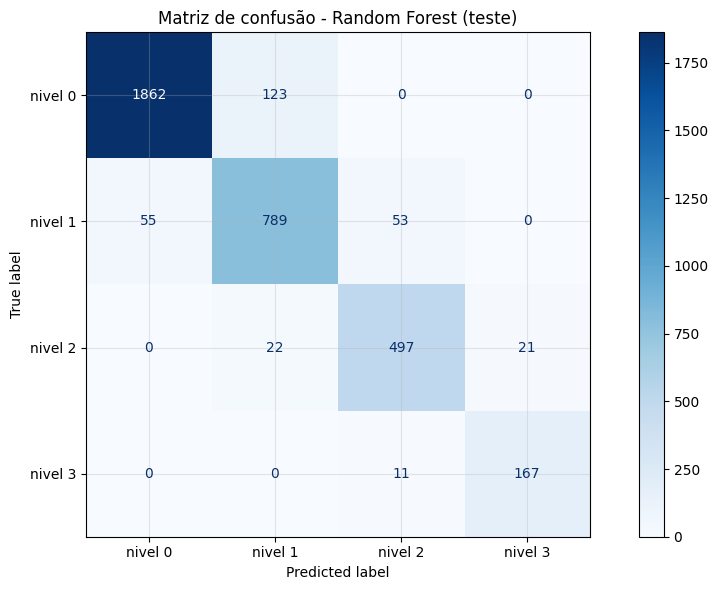

Score sobre os dados com SMOTE:  0.9547172187932988
Score sobre os dados de treino 0.9208333333333333


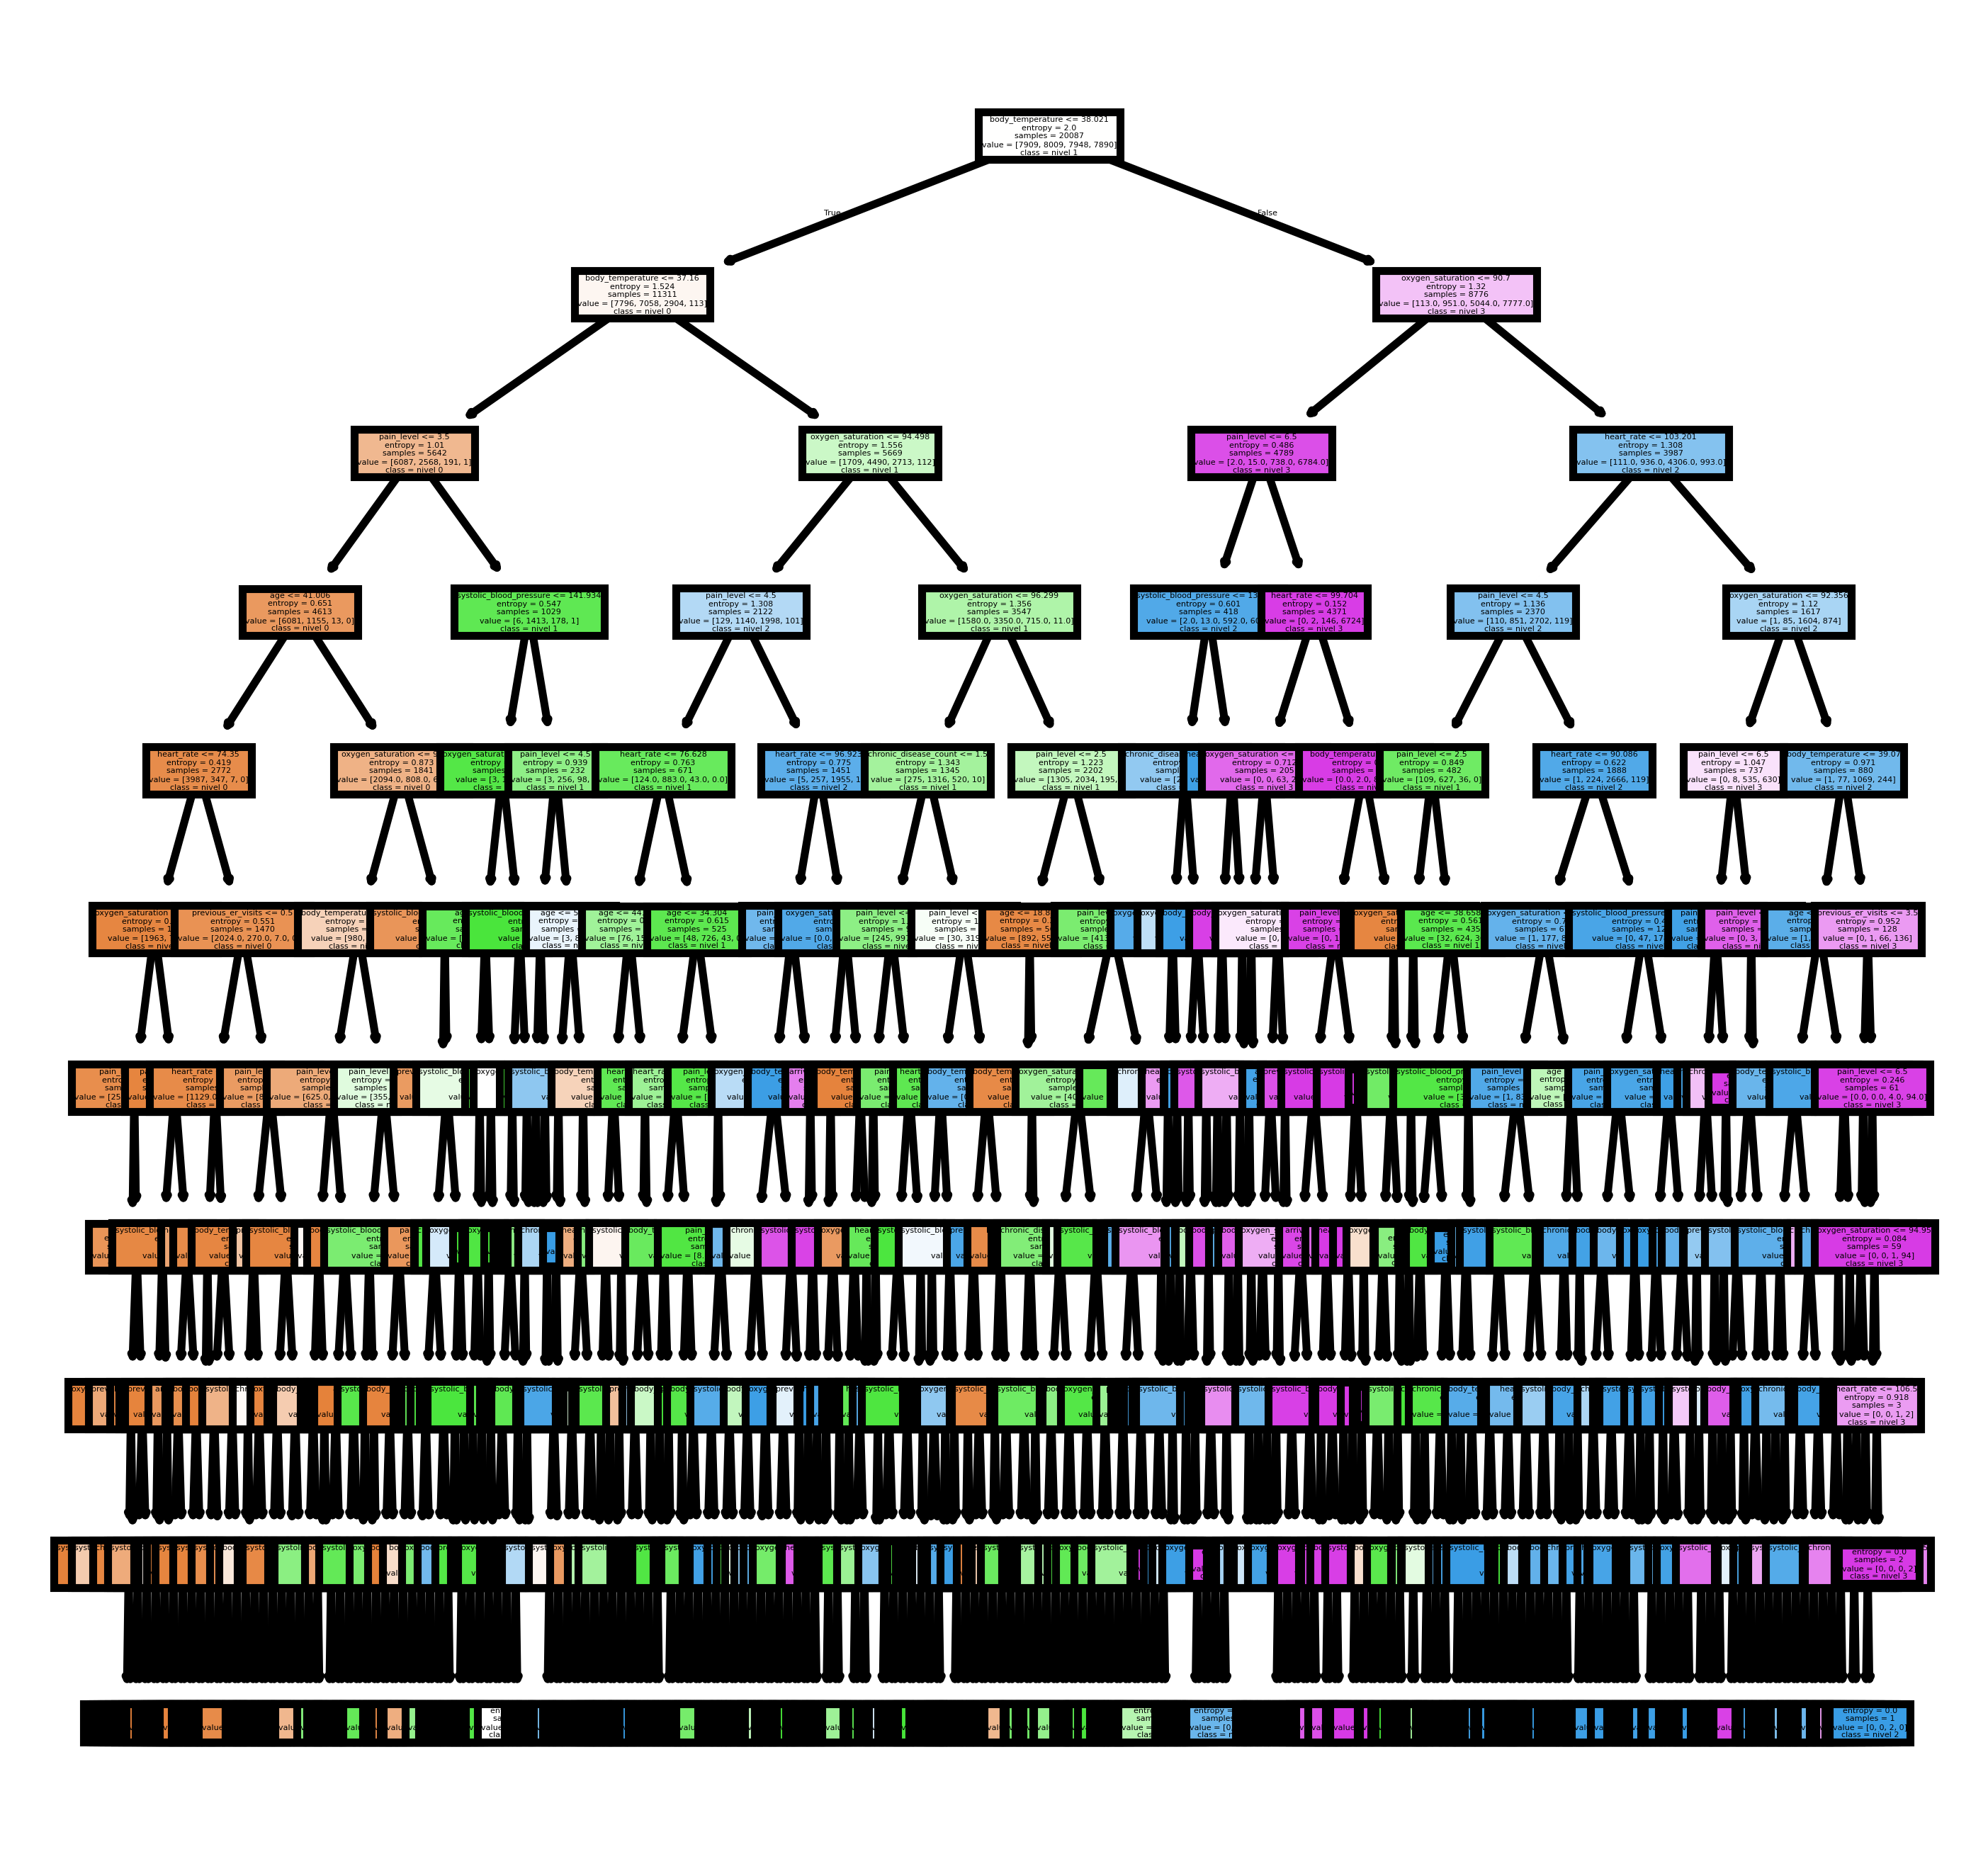

In [85]:
# Balanceamento dos dados (Oversampling)
oversample = SMOTE(random_state=7)
x_train_os, y_train_os = oversample.fit_resample(x_train, y_train)

rf = RandomForestClassifier(
    n_estimators=20,
    criterion='entropy',
    max_depth=10,
    random_state=7,
    class_weight='balanced',
)
rf.fit(x_train_os, y_train_os)

y_predito_random_forest = rf.predict(x_test)

acc_rf_train = rf.score(x_train_os, y_train_os)
acc_rf_test = accuracy_score(y_test, y_predito_random_forest)
print(f"Acurácia (treino com SMOTE): {acc_rf_train:.4f}")
print(f"Acurácia (teste):             {acc_rf_test:.4f}")
print(f"Gap treino-teste:             {acc_rf_train - acc_rf_test:.4f}")
print("\nRelatório por classe (Random Forest — teste):")
print(classification_report(y_test, y_predito_random_forest, target_names=class_names, digits=4))

cm_rf = confusion_matrix(y_test, y_predito_random_forest)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=class_names).plot(cmap="Blues")
plt.title("Matriz de confusão - Random Forest (teste)")
plt.tight_layout()
plt.show()

# Uma árvore individual da floresta (inspeção qualitativa)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(4, 4), dpi=800)
tree.plot_tree(
    rf.estimators_[0],
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
)
fig.savefig('rf_individualtree.png')


### Interpretação — Random Forest (teste)

**Desempenho neste dataset:**
- **Acurácia no teste: 92,4%** — **+4,3 p.p.** acima da Decision Tree (87,8%).
- **Acurácia no treino (SMOTE): ~95,8%** — gap de **~3,4 p.p.**, indicando **leve overfitting**, mas generalização ainda sólida no teste.

**Comparação de revocação (casos graves que o modelo não pode “deixar passar”):**

| Classe | Revocação DT | Revocação RF | Melhoria |
|---|---|---|---|
| Nível 1 | 68,7% | **88,0%** | +19,3 p.p. |
| Nível 2 | 88,9% | **92,0%** | +3,1 p.p. |
| Nível 3 | 84,8% | **94,4%** | +9,6 p.p. |

**Erros clínicos:**
- **Subtriagem:** cai de **236 → 79 casos** (−66%) em relação à Decision Tree.
- Apenas **10 casos** de nível 3 foram previstos como nível 2 (vs 27 na DT).
- **Macro F1:** 0,91 (RF) vs 0,85 (DT) — melhor equilíbrio entre classes minoritárias.

**Conclusão:** o **Random Forest é o melhor modelo** neste notebook: maior acurácia, melhor revocação nas classes urgentes e menos subtriagem. O SMOTE + `class_weight='balanced'` foram decisivos para não ignorar os níveis 2 e 3 (5–15% da base).

### 12) Comparação de modelos — qual escolher e qual métrica usar?

#### Qual foi o melhor modelo?

| Critério | Decision Tree | Random Forest | Vencedor |
|---|---|---|---|
| Acurácia (teste) | 87,8% | **92,4%** | RF |
| Macro F1 (teste) | 0,85 | **0,91** | RF |
| Revocação nível 3 | 84,8% | **94,4%** | RF |
| Subtriagem (pred < real) | 236 casos | **79 casos** | RF |
| Interpretabilidade direta | **Alta** (1 árvore) | Média (floresta) | DT |

**Resposta direta:** adotamos o **Random Forest** como modelo final por desempenho superior em todas as métricas clínicamente relevantes. A Decision Tree permanece como **baseline interpretável**.

#### Qual métrica priorizar no contexto de triagem?

Em pronto-socorro, o custo de **subtriagem** (classificar um caso grave como leve) é **assimétrico e maior** que o de supertriagem (priorizar alguém que poderia esperar).

| Métrica | Quando usar neste projeto |
|---|---|
| **Revocação por classe** (especialmente níveis 2 e 3) | **Métrica principal** — mede quantos casos urgentes o modelo detecta. RF alcança 94,4% no nível 3. |
| **Macro F1** | Compara classes com suporte desigual (55% nível 0 vs 5% nível 3). RF = 0,91. |
| **Matriz de confusão** | Identifica *para onde* vão os erros (ex.: confundir 3→2 é mais grave que 1→0). |
| **Acurácia global** | Visão geral, mas **enganosa** sozinha: um modelo que prevê sempre nível 0 teria ~55% de acurácia sem utilidade clínica. |

#### Treino vs teste — o que aconteceu *neste* experimento?

| Modelo | Score treino | Score teste | Gap | Diagnóstico |
|---|---|---|---|---|
| Decision Tree | 88,7% | 87,8% | 0,9 p.p. | Generaliza bem; underfitting leve (árvore rasa). |
| Random Forest | **95,8%** (SMOTE) | **92,4%** | **3,4 p.p.** | Leve overfitting, mas teste ainda robusto; SMOTE inflaciona levemente o score de treino. |

**Não basta dizer que “treino costuma ser alto”:** aqui o treino RF é de fato **3,4 p.p. acima** do teste — sinal de memorização parcial das amostras sintéticas do SMOTE, porém o teste (dados reais, sem SMOTE) mantém **92,4%**, validando uso exploratório.

#### Próximo passo: interpretabilidade

Na seção **12.1** abaixo, usamos **importância de features (Gini)**, **permutação no teste** e **SHAP** para explicar *por que* o Random Forest toma suas decisões — complementando a matriz de confusão com o *mecanismo* do modelo.

### 12.1) Interpretabilidade — quais variáveis mais influenciaram o Random Forest?

Com o RF escolhido como modelo final, aplicamos três técnicas complementares:

1. **Importância Gini** (nativa do Random Forest): frequência com que cada feature aparece em splits que reduzem impureza.
2. **Importância por permutação** (teste): queda no score ao embaralhar cada coluna — mais conservadora e alinhada à generalização.
3. **SHAP (TreeExplainer)**: contribuição marginal de cada variável por predição; confirma o ranking global.

A interpretação dos gráficos está na célula seguinte.

In [ ]:
# --- 12.1) Interpretabilidade do Random Forest ---

# 1) Importância Gini
imp_gini = pd.Series(rf.feature_importances_, index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp_gini.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black", alpha=0.85)
ax.set_title("Importância Gini — Random Forest")
ax.set_xlabel("Importância relativa")
plt.tight_layout()
plt.show()

# 2) Permutation importance no conjunto de TESTE
perm = permutation_importance(
    rf, x_test, y_test, n_repeats=10, random_state=7, n_jobs=-1, scoring="f1_macro"
)
imp_perm = pd.Series(perm.importances_mean, index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
imp_perm.plot(kind="barh", ax=ax, color="coral", edgecolor="black", alpha=0.85)
ax.set_title("Importância por permutação — Random Forest (teste, F1 macro)")
ax.set_xlabel("Queda média no F1 macro ao embaralhar a feature")
plt.tight_layout()
plt.show()

print("Ranking Gini (top 5):")
print(imp_gini.sort_values(ascending=False).head().round(4).to_string())
print("\nRanking permutação (top 5):")
print(imp_perm.sort_values(ascending=False).head().round(4).to_string())

# 3) SHAP — amostra do teste para performance
shap_sample = x_test.sample(min(500, len(x_test)), random_state=7)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
    max_display=10,
)
plt.title("SHAP — importância média |contribuição| (Random Forest)")
plt.tight_layout()
plt.show()


### Interpretação — importância das variáveis (Random Forest)

**Ranking convergente entre Gini, permutação e SHAP:**

| Posição | Variável | Importância Gini | O que indica |
|---|---|---|---|
| 1 | **`pain_level`** | ~37% | Dor domina as decisões — coerente com correlação 0,90 na EDA. |
| 2 | **`body_temperature`** | ~27% | Febre/hipertermia separa casos graves quando combinada com dor. |
| 3 | **`oxygen_saturation`** | ~16% | SpO₂ baixa empurra predição para níveis mais altos. |
| 4 | **`heart_rate`** | ~7% | Taquicardia contribui, mas com peso menor que dor e temperatura. |
| 5 | **`systolic_blood_pressure`** | ~5% | PA sistólica complementa os sinais vitais. |

**Variáveis de menor peso:** `age`, `arrival_mode_label_encoding`, `previous_er_visits` e `chronic_disease_count` aparecem com importância < 4% cada — ainda úteis (especialmente idade, que a EDA mostrou viés etário), mas **não são os principais drivers** do modelo treinado.

**Coerência EDA ↔ modelo:** as três técnicas confirmam o que o heatmap e os boxplots já sugeriam — **`pain_level` + sinais vitais** (`body_temperature`, `oxygen_saturation`, `heart_rate`) concentram a capacidade preditiva. Isso **valida** as escolhas de features e explica por que erros restantes tendem a ocorrer em casos intermediários (níveis 1↔2), onde dor e vitais se sobrepõem.

**Limitação:** alta dependência de `pain_level` significa que o modelo **replica a subjetividade** da escala de dor — em produção, convém monitorar se populações com sub/notificação de dor diferente degradam o desempenho.

In [86]:
print(y_test.shape)


(3600,)


In [87]:
rf.predict([[38, 91, 158.6, 100, 37.35, 4, 0, 0, 2]])


c:\Users\mikae\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([1])

### 13.0) Discussão crítica de uso prático (resposta direta ao enunciado)

**Modelo recomendado:** Random Forest (92,4% acurácia e 94,4% revocação no nível 3 no teste), com interpretabilidade documentada na seção 12.1 (`pain_level` + sinais vitais como drivers principais).

**O modelo pode ser usado na prática?**
- **Como apoio à decisão clínica (triagem assistida)**, priorizando fila e alertando casos com probabilidade de maior gravidade, mantendo supervisão humana.
- **Não** deve ser usado como decisão autônoma diagnóstica.

**Em que contexto?**
- triagem em pronto atendimento, com integração ao fluxo de recepção/enfermagem;
- uso em tempo real para priorização de atendimento e monitoramento de risco.

**Principais riscos e limitações**
- base utilizada é **sintética**, podendo não refletir toda a variabilidade clínica real;
- **dependência elevada de `pain_level`** (subjetivo) — confirmada por SHAP e importância de features;
- risco de viés por distribuição de classes, faixa etária e modo de chegada;
- desempenho pode cair em hospitais/populações diferentes sem recalibração;
- sensibilidade a mudanças de protocolo clínico ao longo do tempo (drift).

**Validação necessária antes de produção**
- validação externa em dados reais multicêntricos;
- avaliação prospectiva (piloto assistido) com monitoramento contínuo de **revocação nos níveis 2–3**;
- definição de limiares clínicos com equipe médica e governança de risco.

**Papel final do médico**
- a predição é um **sinal de suporte**;
- o(a) médico(a) mantém a decisão final diagnóstica e terapêutica, considerando contexto clínico completo, exame físico e julgamento profissional.